# SAT Mapping

Here, we show that how the optimization problem is mapped to the one-dimensional lattice that is implicitly defined by the MPS evaluator has a large impact on the simulation accuracy.
This is studied for random three-regular graphs.
The topology of an MPS tensor network is linear, and qubits which are strongly entangled should be placed close one to each other when mapping them to the MPS.
To this end, we can therefore use the SAT mapping for hardware developped by Matsuo *et al.* in Ref. [1].
We evaluate depth-one QAOA at a near optimal point and compare the MPS evaluator to the result of the exact efficient depth-one evaluator.

#### References

[1] A. Matsuo, S. Yamashita, D. J. Egger, *"A SAT approach to the initial mapping problem in SWAP gate insertion for commuting gates"*, IEICE Transactions on Fundamentals of Electronics, Communications and Computer Sciences **106**, 11 (2023).

In [ ]:
import time
import matplotlib.pyplot as plt
import numpy as np

from qiskit.transpiler.passes.routing.commuting_2q_gate_routing import SwapStrategy

from qopt_best_practices.sat_mapping import SATMapper

from qaoa_training_pipeline.evaluation import MPSEvaluator, EfficientDepthOneEvaluator, MPSAerEvaluator
from qaoa_training_pipeline.training import DepthOneScanTrainer
from qaoa_training_pipeline.utils.graph_utils import load_graph, graph_to_operator

In [ ]:
indices = list(range(5))
# base_dir = "../QAOA-Parameter-Setting/instances/random_regular/"
# graphs = [load_graph(base_dir + f"00{idx}_40nodes_random3regular.json") for idx in indices]
base_dir = "../instances/line_to_full/"
graphs = [load_graph(base_dir + f"00{idx}_100nodes_2swap_layers.json") for idx in indices]
short_name = "N100L2S2" 
cost_ops = [graph_to_operator(graph, pre_factor=-0.5) for graph in graphs]

In [12]:
ed_evaluator = EfficientDepthOneEvaluator()

trainers = [DepthOneScanTrainer(ed_evaluator) for _ in graphs]

In [13]:
swap_strategy = SwapStrategy.from_line(range(graphs[0].order()))
sat_graphs, n_layers, mapping_times = [], [], []

for idx, graph in enumerate(graphs):
    start = time.time()
    sat_graph, _, layers = SATMapper(timeout=10).remap_graph_with_sat(graph=graph, swap_strategy=swap_strategy)
    mapping_times.append(time.time() - start)
    print(f"Mapped graph {idx} in {mapping_times[-1]:.0f}sec")
    n_layers.append(layers)
    sat_graphs.append(sat_graph)

Mapped graph 0 in 61sec
Mapped graph 1 in 58sec
Mapped graph 2 in 57sec
Mapped graph 3 in 59sec
Mapped graph 4 in 57sec


In [14]:
graphs[0].edges(data=True)

EdgeDataView([(0, 1, {'weight': 1}), (0, 3, {'weight': 1}), (0, 5, {'weight': 1}), (1, 2, {'weight': 1}), (1, 3, {'weight': 1}), (3, 2, {'weight': 1}), (3, 4, {'weight': -1}), (5, 2, {'weight': -1}), (5, 4, {'weight': -1}), (5, 6, {'weight': 1}), (2, 7, {'weight': 1}), (7, 4, {'weight': -1}), (7, 6, {'weight': -1}), (7, 8, {'weight': -1}), (4, 9, {'weight': 1}), (9, 6, {'weight': 1}), (9, 8, {'weight': -1}), (9, 10, {'weight': -1}), (6, 11, {'weight': 1}), (11, 8, {'weight': -1}), (11, 10, {'weight': 1}), (11, 12, {'weight': -1}), (8, 13, {'weight': 1}), (13, 10, {'weight': 1}), (13, 12, {'weight': 1}), (13, 14, {'weight': -1}), (10, 15, {'weight': -1}), (15, 12, {'weight': -1}), (15, 14, {'weight': 1}), (15, 16, {'weight': 1}), (12, 17, {'weight': -1}), (17, 14, {'weight': 1}), (17, 16, {'weight': -1}), (17, 18, {'weight': 1}), (14, 19, {'weight': 1}), (19, 16, {'weight': 1}), (19, 18, {'weight': -1}), (19, 20, {'weight': 1}), (16, 21, {'weight': 1}), (21, 18, {'weight': -1}), (21, 20

In [15]:
sat_graphs[0].edges(data=True)

EdgeDataView([(99, 98, {'weight': 1}), (99, 96, {'weight': 1}), (99, 94, {'weight': 1}), (98, 97, {'weight': 1}), (98, 96, {'weight': 1}), (96, 97, {'weight': 1}), (96, 95, {'weight': -1}), (94, 97, {'weight': -1}), (94, 95, {'weight': -1}), (94, 93, {'weight': 1}), (97, 92, {'weight': 1}), (92, 95, {'weight': -1}), (92, 93, {'weight': -1}), (92, 91, {'weight': -1}), (95, 90, {'weight': 1}), (90, 93, {'weight': 1}), (90, 91, {'weight': -1}), (90, 89, {'weight': -1}), (93, 88, {'weight': 1}), (88, 91, {'weight': -1}), (88, 89, {'weight': 1}), (88, 87, {'weight': -1}), (91, 86, {'weight': 1}), (86, 89, {'weight': 1}), (86, 87, {'weight': 1}), (86, 85, {'weight': -1}), (89, 84, {'weight': -1}), (84, 87, {'weight': -1}), (84, 85, {'weight': 1}), (84, 83, {'weight': 1}), (87, 82, {'weight': -1}), (82, 85, {'weight': 1}), (82, 83, {'weight': -1}), (82, 81, {'weight': 1}), (85, 80, {'weight': 1}), (80, 83, {'weight': 1}), (80, 81, {'weight': -1}), (80, 79, {'weight': 1}), (83, 78, {'weight': 

In [16]:
all_params, all_trainers, all_results = [], [], []

for cost_op in cost_ops:
    trainer = DepthOneScanTrainer(EfficientDepthOneEvaluator())
    all_results.append(trainer.train(cost_op, parameter_ranges=((0, np.pi/2), (0, np.pi/2))))
    all_params.append(all_results[-1]["optimized_params"])
    all_trainers.append(trainer)

(<Figure size 640x480 with 2 Axes>,
 <Axes: xlabel='$\\gamma$', ylabel='$\\beta$'>)

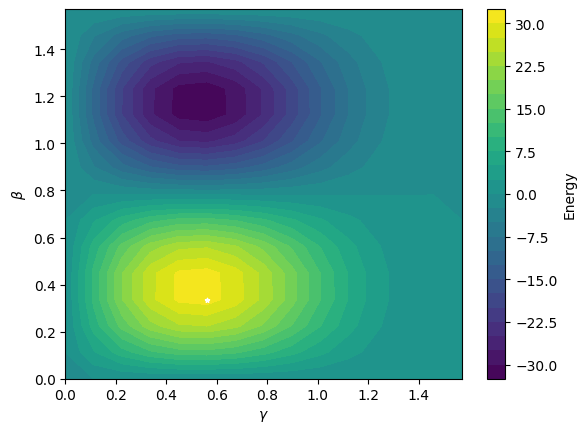

In [17]:
all_trainers[0].plot()

In [18]:
def get_mps_evaluator(bond_dim, truncation_threshold=1.0e-10) -> MPSEvaluator:
    return MPSEvaluator(
        bond_dim_circuit=bond_dim, 
        threshold_circuit=truncation_threshold, 
        use_vidal_form=True, 
        use_swap_strategy=True,
        store_schmidt_values=True,
        store_intermediate_schmidt_values=True
    )

In [19]:
def get_mps_aer_evaluator(bond_dim, truncation_threshold=1.0e-10) -> MPSAerEvaluator:
    mps_init_args= {
                    "matrix_product_state_max_bond_dimension": bond_dim,
                    "matrix_product_state_truncation_threshold": truncation_threshold,
                    "method": "matrix_product_state"
                }
    return MPSAerEvaluator(
        mps_init_args=mps_init_args
    )

In [20]:
ed_evaluator = EfficientDepthOneEvaluator()
sat_cost_ops = []
all_sat_ed_energies, all_ed_energies = [], []
all_mps_energies = {"Quimb": [], "Aer": []}
all_sat_mps_energies = {"Quimb": [], "Aer": []}
all_times = {"Quimb": [], "Aer": []}
all_sat_times = {"Quimb": [], "Aer": []}
all_bounds, all_sat_bounds = [], []
all_estimates, all_sat_estimates = [], []

bond_dims = [2, 4, 8, 16, 32, 64]

for bond_dim in bond_dims:
    print(f"Bond dimension {bond_dim}")
    sat_ed_energies, ed_energies = [], []
    
    mps_energies, sat_mps_energies = [],[]
    mps_aer_energies, sat_mps_aer_energies = [],[]
    times, sat_times = [], []
    aer_times, aer_sat_times = [], []

    # sat_bounds, bounds = [], []
    # sat_estimates, estimates = [], []
    
    for idx, sat_graph in enumerate(sat_graphs):
        print(f"On index {idx}")

        #params = [1, 1]
        params = all_params[idx]
        
        sat_cost_ops.append(graph_to_operator(sat_graph, pre_factor=-0.5))
        ed_energies.append(float(ed_evaluator.evaluate(cost_ops[idx], params)))
        sat_ed_energies.append(float(ed_evaluator.evaluate(sat_cost_ops[-1], params)))
    
        mps_evaluator_1 = get_mps_evaluator(bond_dim)
        mps_evaluator_2 = get_mps_evaluator(bond_dim)
        mps_aer_evaluator_1 = get_mps_aer_evaluator(bond_dim)
        mps_aer_evaluator_2 = get_mps_aer_evaluator(bond_dim)

        start = time.time()
        mps_energies.append(float(mps_evaluator_1.evaluate(cost_ops[idx], params)))
        times.append(time.time() - start)

        start = time.time()
        sat_mps_energies.append(float(mps_evaluator_2.evaluate(sat_cost_ops[-1], params)))
        sat_times.append(time.time() - start)

        start = time.time()
        mps_aer_energies.append(float(mps_aer_evaluator_1.evaluate(cost_ops[idx], params)))
        aer_times.append(time.time() - start)

        start = time.time()
        sat_mps_aer_energies.append(float(mps_aer_evaluator_2.evaluate(sat_cost_ops[-1], params)))
        aer_sat_times.append(time.time() - start)
        
        # bounds.append(mps_evaluator_1.calculate_fidelity_lower_bound())
        # sat_bounds.append(mps_evaluator_2.calculate_fidelity_lower_bound())
        # estimates.append(mps_evaluator_1.calculate_fidelity_approximation())
        # sat_estimates.append(mps_evaluator_2.calculate_fidelity_approximation())
        

    all_ed_energies.append(ed_energies)
    all_sat_ed_energies.append(sat_ed_energies)
    all_mps_energies["Quimb"].append(mps_energies)
    all_sat_mps_energies["Quimb"].append(sat_mps_energies)
    all_times["Quimb"].append(times)
    all_sat_times["Quimb"].append(sat_times)

    all_mps_energies["Aer"].append(mps_aer_energies)
    all_sat_mps_energies["Aer"].append(sat_mps_aer_energies)
    all_times["Aer"].append(aer_times)
    all_sat_times["Aer"].append(aer_sat_times)
    
    # all_bounds.append(bounds)
    # all_sat_bounds.append(sat_bounds)
    # all_estimates.append(estimates)
    # all_sat_estimates.append(sat_estimates)

Bond dimension 2
On index 0
On index 1
On index 2
On index 3
On index 4
Bond dimension 4
On index 0
On index 1
On index 2
On index 3
On index 4
Bond dimension 8
On index 0
On index 1
On index 2
On index 3
On index 4
Bond dimension 16
On index 0
On index 1
On index 2
On index 3
On index 4
Bond dimension 32
On index 0
On index 1
On index 2
On index 3
On index 4
Bond dimension 64
On index 0
On index 1
On index 2
On index 3
On index 4


In [21]:
assert np.allclose(ed_energies, sat_ed_energies)

In [22]:
all_ed_energies = np.array(all_ed_energies)
all_sat_ed_energies = np.array(all_sat_ed_energies)
all_mps_energies = np.array(all_mps_energies)
all_sat_mps_energies = np.array(all_sat_mps_energies)
all_times = np.array(all_times)
all_sat_times = np.array(all_sat_times)
# all_bounds = np.array(all_bounds)
# all_sat_bounds = np.array(all_sat_bounds)
# all_estimates = np.array(all_estimates)
# all_sat_estimates = np.array(all_sat_estimates)

In [23]:
all_mps_energies = all_mps_energies.item()
all_sat_mps_energies = all_sat_mps_energies.item()
all_times = all_times.item()
all_sat_times = all_sat_times.item()
# all_bounds = all_bounds.item()
# all_sat_bounds = all_sat_bounds.item()

In [24]:
rel_errors = (all_mps_energies["Quimb"] - all_ed_energies)/all_ed_energies
rel_sat_errors = (all_sat_mps_energies["Quimb"] - all_ed_energies)/all_ed_energies
rel_aer_errors = (all_mps_energies["Aer"] - all_ed_energies)/all_ed_energies
rel_aer_sat_errors = (all_sat_mps_energies["Aer"] - all_ed_energies)/all_ed_energies

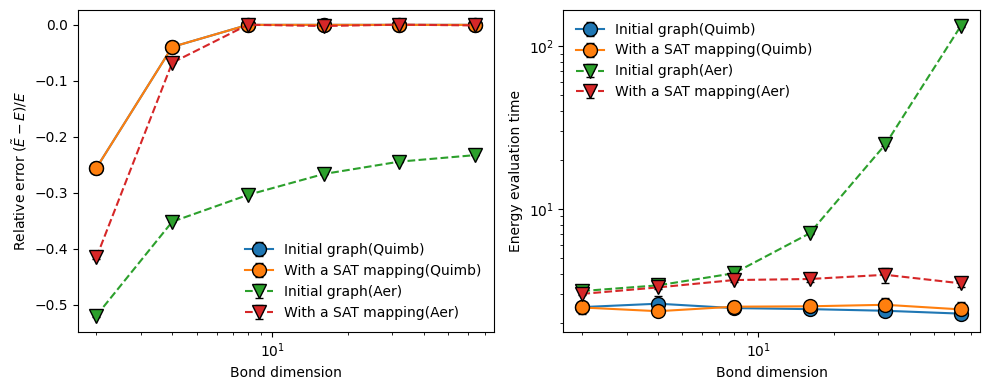

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

opts = {"marker": "o", "mec": "k", "ecolor": "k", "capsize": 3, "elinewidth": 1, "linestyle":'-',"ms":10}
opts2 = {"marker": "v", "mec": "k", "ecolor": "k", "capsize": 3, "elinewidth": 1, "linestyle":'--',"ms":10}

axs[0].errorbar(bond_dims, np.average(rel_errors, axis=1), yerr=np.std(rel_errors, axis=1), label="Initial graph(Quimb)", **opts)
axs[0].errorbar(bond_dims, np.average(rel_sat_errors, axis=1), yerr=np.std(rel_sat_errors, axis=1), label="With a SAT mapping(Quimb)", **opts)
axs[0].errorbar(bond_dims, np.average(rel_aer_errors, axis=1), yerr=np.std(rel_errors, axis=1), label="Initial graph(Aer)", **opts2)
axs[0].errorbar(bond_dims, np.average(rel_aer_sat_errors, axis=1), yerr=np.std(rel_sat_errors, axis=1), label="With a SAT mapping(Aer)", **opts2)
axs[0].set_ylabel(r"Relative error $(\tilde{E}-E)/E$")
axs[0].set_xlabel("Bond dimension")
axs[0].legend(frameon=False)
axs[0].set_xscale("log")

axs[1].errorbar(bond_dims, np.average(all_times["Quimb"], axis=1), yerr=np.std(all_times["Quimb"], axis=1), label="Initial graph(Quimb)", **opts)
axs[1].errorbar(bond_dims, np.average(all_sat_times["Quimb"], axis=1), yerr=np.std(all_sat_times["Quimb"], axis=1), label="With a SAT mapping(Quimb)", **opts)
axs[1].errorbar(bond_dims, np.average(all_times["Aer"], axis=1), yerr=np.std(all_times["Aer"], axis=1), label="Initial graph(Aer)", **opts2)
axs[1].errorbar(bond_dims, np.average(all_sat_times["Aer"], axis=1), yerr=np.std(all_sat_times["Aer"], axis=1), label="With a SAT mapping(Aer)", **opts2)
axs[1].set_ylabel(r"Energy evaluation time")
axs[1].set_xlabel("Bond dimension")
axs[1].legend(frameon=False)
axs[1].set_xscale("log")
axs[1].set_yscale("log")

fig.tight_layout()
fig.savefig(f"{short_name}_sat_mapping_impact.pdf", bbox_inches="tight")

In [26]:
print("Average and std of relative error without SAT")
print(np.average(rel_errors, axis=1))
print(np.std(rel_errors, axis=1))
print("Average and std of relative error with SAT")
print(np.average(rel_sat_errors, axis=1))
print(np.std(rel_sat_errors, axis=1))
print("Average and std of Aer relative error without SAT")
print(np.average(rel_aer_errors, axis=1))
print(np.std(rel_aer_errors, axis=1))
print("Average and std of Aer relative error with SAT")
print(np.average(rel_aer_sat_errors, axis=1))
print(np.std(rel_aer_sat_errors, axis=1))

Average and std of relative error without SAT
[-2.55487813e-01 -3.94637168e-02  6.24803024e-15  6.24803024e-15
  6.24803024e-15  6.24803024e-15]
[3.45329268e-03 5.59666765e-04 5.27566847e-15 5.27566847e-15
 5.27566847e-15 5.27566847e-15]
Average and std of relative error with SAT
[-2.55487813e-01 -3.94637168e-02  7.70990846e-15  7.70990846e-15
  7.70990846e-15  7.70990846e-15]
[3.45329268e-03 5.59666765e-04 5.75161791e-15 5.75161791e-15
 5.75161791e-15 5.75161791e-15]
Average and std of Aer relative error without SAT
[-0.51921917 -0.35166888 -0.30375282 -0.26642062 -0.24431631 -0.23269307]
[0.03873247 0.01569666 0.0069745  0.00578792 0.00659915 0.00424833]
Average and std of Aer relative error with SAT
[-4.14992813e-01 -6.76674878e-02  1.47943496e-04 -2.05401851e-03
  3.76590240e-04 -1.06090101e-03]
[0.02469302 0.00243769 0.0017099  0.00339899 0.0023154  0.0029306 ]


In [27]:
print("Average SAT mapping times with std in seconds")
print(np.average(mapping_times), np.std(mapping_times))

Average SAT mapping times with std in seconds
58.235765838623045 1.4266495265242891
